# Faster bivariate-normal CDF for the pairwise composite likelihood

**Goal.** Speed up the hot spot of the spatial-BMCD pairwise MLE
(`mle_sigma_pairwise*`), namely the bivariate Gaussian CDF

$$q_\text{joint}=\Phi_2\!\bigl(z_{n,j},\,z_{n,j'};\,\rho^\star\bigr)$$

computed by `phi2` (see `spatial_model.py`). Today `phi2` builds a fresh
`scipy.stats.multivariate_normal` object and runs Genz QMC on **every** call
inside the double `for j,k` loop — tens of millions of heavyweight calls per fit.

The marginals are already exact and free ($\Phi(z_j)=q_j$ since $z=\Phi^{-1}(q)$),
so only the bivariate term needs accelerating.

This notebook **implements and compares** the speedup methods of the plan
(`old_plan_approximate_bivariate_cdf.md`):

| # | Method | What changes |
|---|--------|--------------|
| 0 | **`phi2_scipy`** (baseline) | current code: fresh `multivariate_normal(...).cdf` per call |
| 1 | **`phi2_genz_scalar`** | in-house Genz `BVND` (Drezner–Wesolowsky / Gauss–Legendre), pure-Python scalar, adaptive node count → removes scipy object construction |
| 2 | **`phi2_genz`** (vectorized) | same algorithm written with `numpy`/`np.where` and a fixed 10-node set → array-capable, enables killing the Python pair loop |
| 3 | **`phi2_fastnorm`** | third-party [`fastnorm`](https://pypi.org/project/fastnorm/) drop-in; fast but **scalar-only here** (its vectorization needs one shared $\rho$, we have per-pair $\rho$) and **approximate** ($\sim10^{-7}$) |

We verify (a) **accuracy is kept** (max abs error vs scipy), (b) **per-call
acceleration**, and (c) the **loop-level** win when the whole pair loop is
vectorized (plan Deliverable 2). Everything below is self-contained — no ECAD
data needed.

In [1]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

rng = np.random.default_rng(0)
TWOPI = 2.0 * np.pi
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
print("numpy", np.__version__)

numpy 2.4.6


## Method 0 — baseline: scipy `multivariate_normal` (current `phi2`)

This is exactly the body of `phi2` in `spatial_model.py`: it allocates a frozen
`multivariate_normal` distribution (with a fresh $2\times2$ covariance) on every
call and evaluates its CDF with Genz's general QMC routine. Correct, but the
per-call object construction dominates the cost.

In [2]:
def phi2_scipy(z1, z2, rho):
    '''Bivariate standard-normal CDF Phi_2(z1,z2;rho) -- current implementation.'''
    rho = float(np.clip(rho, -0.999999, 0.999999))
    cov = np.array([[1.0, rho], [rho, 1.0]], dtype=float)
    return float(multivariate_normal(mean=[0.0, 0.0], cov=cov).cdf([z1, z2]))

phi2_scipy(0.5, -0.3, 0.7)

0.3567836347968547

## Gauss–Legendre node sets (Genz 2004, Table from `tvpack`)

`BVND` uses three Gauss–Legendre rules and picks one by $|r|$ (3 / 6 / 10 nodes,
each used via $\pm$ symmetry). The scalar method uses the adaptive choice; the
vectorized method always uses the 10-node rule (a tiny bit more work for small
$r$, but fully array-friendly and still $\sim10^{-15}$ accurate).

In [3]:
# (weight, node) pairs; nodes are negative, mirrored by +/- symmetry.
_GL6 = [  # |r| < 0.30  -> 3 nodes
    (0.1713244923791705e+00, -0.9324695142031522e+00),
    (0.3607615730481384e+00, -0.6612093864662647e+00),
    (0.4679139345726904e+00, -0.2386191860831970e+00),
]
_GL12 = [  # 0.30 <= |r| < 0.75 -> 6 nodes
    (0.4717533638651177e-01, -0.9815606342467191e+00),
    (0.1069393259953183e+00, -0.9041172563704750e+00),
    (0.1600783285433464e+00, -0.7699026741943050e+00),
    (0.2031674267230659e+00, -0.5873179542866171e+00),
    (0.2334925365383547e+00, -0.3678314989981802e+00),
    (0.2491470458134029e+00, -0.1252334085114692e+00),
]
_GL20 = [  # |r| >= 0.75 (and the whole vectorized path) -> 10 nodes
    (0.1761400713915212e-01, -0.9931285991850949e+00),
    (0.4060142980038694e-01, -0.9639719272779138e+00),
    (0.6267204833410906e-01, -0.9122344282513259e+00),
    (0.8327674157670475e-01, -0.8391169718222188e+00),
    (0.1019301198172404e+00, -0.7463319064601508e+00),
    (0.1181945319615184e+00, -0.6360536807265150e+00),
    (0.1316886384491766e+00, -0.5108670019508271e+00),
    (0.1420961093183821e+00, -0.3737060887154196e+00),
    (0.1491729864726037e+00, -0.2277858511416451e+00),
    (0.1527533871307259e+00, -0.7652652113349733e-01),
]
W20 = np.array([p[0] for p in _GL20])
X20 = np.array([p[1] for p in _GL20])
print("node counts:", len(_GL6), len(_GL12), len(_GL20))

node counts: 3 6 10


## Method 1 — in-house Genz `BVND`, pure-Python scalar (drop-in `phi2`)

`_bvnd_scalar(dh, dk, r)` returns the upper-tail $P(X>dh,\,Y>dk)$ for a standard
bivariate normal with correlation $r$ (Genz 2004, the Drezner–Wesolowsky
Gauss–Legendre quadrature with the $|r|<0.925$ integral branch and the
$|r|\ge0.925$ near-boundary expansion). The lower-tail CDF then follows from the
$(-X,-Y)$ symmetry, which preserves $r$:

$$\Phi_2(z_1,z_2;\rho)=P(X>-z_1,\,Y>-z_2)=\texttt{\_bvnd}(-z_1,-z_2,\rho).$$

This is a *drop-in* replacement for `phi2` — same scalar signature — that simply
removes scipy's per-call object construction. We use `math.erfc` for $\Phi$ to
keep the scalar path light.

In [4]:
_SQRT2 = math.sqrt(2.0)
def _phid(x):  # standard normal CDF, scalar
    return 0.5 * math.erfc(-x / _SQRT2)


def _bvnd_scalar(dh, dk, r):
    '''P(X>dh, Y>dk), standard bivariate normal, correlation r (Genz 2004).'''
    if abs(r) < 0.30:
        gl = _GL6
    elif abs(r) < 0.75:
        gl = _GL12
    else:
        gl = _GL20
    h, k = dh, dk
    hk = h * k
    bvn = 0.0
    if abs(r) < 0.925:
        if r != 0.0:
            hs = (h * h + k * k) / 2.0
            asr = math.asin(r)
            for w, x in gl:
                for sgn in (-1.0, 1.0):
                    sn = math.sin(asr * (sgn * x + 1.0) / 2.0)
                    bvn += w * math.exp((sn * hk - hs) / (1.0 - sn * sn))
            bvn = bvn * asr / (2.0 * TWOPI)
        bvn += _phid(-h) * _phid(-k)
    else:
        if r < 0.0:
            k = -k
            hk = -hk
        if abs(r) < 1.0:
            as_ = (1.0 - r) * (1.0 + r)
            a = math.sqrt(as_)
            bs = (h - k) ** 2
            c = (4.0 - hk) / 8.0
            d = (12.0 - hk) / 16.0
            asr = -(bs / as_ + hk) / 2.0
            if asr > -100.0:
                bvn = a * math.exp(asr) * (1 - c * (bs - as_) * (1 - d * bs / 5) / 3
                                           + c * d * as_ * as_ / 5)
            if -hk < 100.0:
                b = math.sqrt(bs)
                bvn -= (math.exp(-hk / 2.0) * math.sqrt(TWOPI) * _phid(-b / a) * b
                        * (1 - c * bs * (1 - d * bs / 5) / 3))
            a = a / 2.0
            for w, x in gl:
                for sgn in (-1.0, 1.0):
                    xs = (a * (sgn * x + 1.0)) ** 2
                    rs = math.sqrt(1.0 - xs)
                    asr = -(bs / xs + hk) / 2.0
                    if asr > -100.0:
                        bvn += a * w * math.exp(asr) * (
                            math.exp(-hk * xs / (2 * (1 + rs) ** 2)) / rs
                            - (1 + c * xs * (1 + d * xs)))
            bvn = -bvn / TWOPI
        if r > 0.0:
            bvn += _phid(-max(h, k))
        else:
            bvn = -bvn
            if k > h:
                bvn += _phid(k) - _phid(h)
    return bvn


def phi2_genz_scalar(z1, z2, rho):
    rho = float(np.clip(rho, -0.999999, 0.999999))
    return _bvnd_scalar(-z1, -z2, rho)

phi2_genz_scalar(0.5, -0.3, 0.7), phi2_scipy(0.5, -0.3, 0.7)

(0.3567836347968547, 0.3567836347968547)

## Method 2 — vectorized Genz `BVND` (`numpy` + `np.where`)

The same algorithm, written with elementwise `numpy` ops and `np.where` for the
two branches, using the **fixed 10-node** rule for all elements. It accepts
arrays of `(dh, dk, r)` and computes every pair in one shot — both branches are
evaluated everywhere and selected by mask (`np.errstate` silences the discarded
branch's harmless overflow). This is what lets us later replace the whole
`for j,k` loop with a single call (Deliverable 2).

In [5]:
def _bvnd(dh, dk, r):
    '''Vectorized P(X>dh, Y>dk), standard bivariate normal, correlation r.'''
    dh, dk, r = np.broadcast_arrays(np.asarray(dh, float),
                                    np.asarray(dk, float),
                                    np.asarray(r, float))
    h = np.array(dh, float); k = np.array(dk, float)
    hk = h * k
    low = np.abs(r) < 0.925
    with np.errstate(all="ignore"):
        # ---- branch A: |r| < 0.925 (integral form) ----
        hs = (h * h + k * k) / 2.0
        asr = np.arcsin(np.clip(r, -1.0, 1.0))
        accA = np.zeros_like(h)
        for w, x in zip(W20, X20):
            for sgn in (-1.0, 1.0):
                sn = np.sin(asr * (sgn * x + 1.0) / 2.0)
                accA += w * np.exp((sn * hk - hs) / (1.0 - sn * sn))
        bvnA = accA * asr / (2.0 * TWOPI) + norm.cdf(-h) * norm.cdf(-k)

        # ---- branch B: |r| >= 0.925 (near-boundary expansion) ----
        kB = np.where(r < 0, -k, k)
        hkB = np.where(r < 0, -hk, hk)
        asB = (1.0 - r) * (1.0 + r)
        aB = np.sqrt(np.abs(asB))
        bsB = (h - kB) ** 2
        cB = (4.0 - hkB) / 8.0
        dB = (12.0 - hkB) / 16.0
        asr0 = -(bsB / asB + hkB) / 2.0
        bvnB = np.where(asr0 > -100,
                        aB * np.exp(asr0) * (1 - cB * (bsB - asB) * (1 - dB * bsB / 5) / 3
                                             + cB * dB * asB * asB / 5),
                        0.0)
        bB = np.sqrt(bsB)
        term2 = (np.exp(-hkB / 2.0) * np.sqrt(TWOPI) * norm.cdf(-bB / aB) * bB
                 * (1 - cB * bsB * (1 - dB * bsB / 5) / 3))
        bvnB = bvnB - np.where(-hkB < 100, term2, 0.0)
        aB2 = aB / 2.0
        accB = np.zeros_like(h)
        for w, x in zip(W20, X20):
            for sgn in (-1.0, 1.0):
                xs = (aB2 * (sgn * x + 1.0)) ** 2
                rs = np.sqrt(1.0 - xs)
                asr2 = -(bsB / xs + hkB) / 2.0
                contrib = (aB2 * w * np.exp(asr2)
                           * (np.exp(-hkB * xs / (2 * (1 + rs) ** 2)) / rs
                              - (1 + cB * xs * (1 + dB * xs))))
                accB += np.where(asr2 > -100, contrib, 0.0)
        bvnB = -(bvnB + accB) / TWOPI
        bvnB = np.where(r > 0,
                        bvnB + norm.cdf(-np.maximum(h, kB)),
                        -bvnB + np.where(kB > h, norm.cdf(kB) - norm.cdf(h), 0.0))
    return np.where(low, bvnA, bvnB)


def phi2_genz(z1, z2, rho):
    '''Vectorized Phi_2(z1,z2;rho). Accepts scalars or arrays.'''
    rho = np.clip(rho, -0.999999, 0.999999)
    return _bvnd(-np.asarray(z1, float), -np.asarray(z2, float), np.asarray(rho, float))

# scalar use returns a 0-d array; wrap with float() for a drop-in replacement
float(phi2_genz(0.5, -0.3, 0.7)), phi2_scipy(0.5, -0.3, 0.7)

(0.3567836347968547, 0.3567836347968547)

## Method 3 — third-party `fastnorm` (scalar drop-in)

[`fastnorm`](https://pypi.org/project/fastnorm/) ships a fast bivariate-normal
CDF `bivar_norm_cdf([x1, x2], correl)` returning $P(X<x_1,\,Y<x_2)$ — a direct
drop-in for `phi2`. Its vectorized form accepts an **array of points but only a
single scalar `correl`**. In the pairwise likelihood each pair carries its own
correlation $\rho=(-1)^{R_j+R_{j'}}C_{jj'}$, so the shared-$\rho$ vectorization is
unusable and `fastnorm` can only be called **once per pair** — i.e. exactly like
the scalar Method 1, just with a third-party kernel instead of our own.

Two caveats versus the Genz methods: it is an **approximation** (max error
$\sim10^{-7}$ here, vs $\sim10^{-16}$ for Methods 1–2) and it **cannot be
vectorized over $\rho$**, so it never reaches the batched regime that gives
Method 2 its largest win.

In [6]:
import fastnorm  # https://pypi.org/project/fastnorm/

def phi2_fastnorm(z1, z2, rho):
    '''Phi_2(z1,z2;rho) via the third-party `fastnorm` (scalar drop-in).

    fastnorm.bivar_norm_cdf accepts vectorized points but only a *scalar*
    correlation, so with per-pair rho it must be called one pair at a time.'''
    rho = float(np.clip(rho, -0.999999, 0.999999))
    return float(fastnorm.bivar_norm_cdf([z1, z2], rho))

phi2_fastnorm(0.5, -0.3, 0.7), phi2_scipy(0.5, -0.3, 0.7)

(0.3567836825596294, 0.3567836347968547)

## Verification 1 — accuracy is kept (vs scipy)

We mesh $z_1,z_2\in[-3.5,3.5]$ against
$\rho\in\{0,\pm0.3,\pm0.6,\pm0.9,\pm0.99,\pm0.999\}$ — deliberately spanning the
$|r|\ge0.925$ branch — and compare each method to
`scipy.stats.multivariate_normal(...).cdf`. Because `phi2` is the *only* thing
that changes in the inference, matching scipy here is sufficient proof that
`sigma_hat` is unaffected. We assert $\max|\Delta|<10^{-5}$ (we expect
$\sim10^{-12}$).

In [7]:
zs = np.linspace(-3.5, 3.5, 21)
rhos = [0.0, 0.3, -0.3, 0.6, -0.6, 0.9, -0.9, 0.99, -0.99, 0.999, -0.999]

Z1, Z2 = np.meshgrid(zs, zs)
err_scalar = np.zeros((len(rhos), Z1.size))
err_vec = np.zeros((len(rhos), Z1.size))
err_fastnorm = np.zeros((len(rhos), Z1.size))
for ir, rho in enumerate(rhos):
    ref = np.array([phi2_scipy(a, b, rho) for a, b in zip(Z1.ravel(), Z2.ravel())])
    sca = np.array([phi2_genz_scalar(a, b, rho) for a, b in zip(Z1.ravel(), Z2.ravel())])
    vec = np.asarray(phi2_genz(Z1.ravel(), Z2.ravel(), np.full(Z1.size, rho)))
    fst = np.array([phi2_fastnorm(a, b, rho) for a, b in zip(Z1.ravel(), Z2.ravel())])
    err_scalar[ir] = np.abs(sca - ref)
    err_vec[ir] = np.abs(vec - ref)
    err_fastnorm[ir] = np.abs(fst - ref)

max_err_scalar = err_scalar.max()
max_err_vec = err_vec.max()
max_err_fastnorm = err_fastnorm.max()
print(f"Method 1 (genz scalar)     max |Delta| vs scipy = {max_err_scalar:.3e}")
print(f"Method 2 (genz vectorized) max |Delta| vs scipy = {max_err_vec:.3e}")
print(f"Method 3 (fastnorm)        max |Delta| vs scipy = {max_err_fastnorm:.3e}")
assert max_err_scalar < 1e-5, "scalar accuracy regression!"
assert max_err_vec < 1e-5, "vectorized accuracy regression!"
assert max_err_fastnorm < 1e-5, "fastnorm accuracy regression!"
print("OK -- Genz methods match scipy to ~1e-15 (effectively machine precision);")
print("      fastnorm is an approximation to ~1e-7 (still well within the 1e-5 tolerance).")

Method 1 (genz scalar)     max |Delta| vs scipy = 2.220e-16
Method 2 (genz vectorized) max |Delta| vs scipy = 2.220e-16
Method 3 (fastnorm)        max |Delta| vs scipy = 1.379e-07
OK -- Genz methods match scipy to ~1e-15 (effectively machine precision);
      fastnorm is an approximation to ~1e-7 (still well within the 1e-5 tolerance).


## Verification 2 — per-call acceleration

We time `N` random calls of each method. The scalar methods are called in a
Python loop (as the current `for j,k` loop does); the vectorized method is timed
both **element-by-element** (to expose numpy's per-call overhead) and
**batched** (one call on the whole array — the regime that actually matters once
the pair loop is vectorized).

In [8]:
def time_it(fn, repeat=3):
    best = math.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

N = 20000
z1s = rng.uniform(-3.0, 3.0, N)
z2s = rng.uniform(-3.0, 3.0, N)
rrs = rng.uniform(-0.97, 0.97, N)

# scipy baseline (use a smaller N -- it is very slow)
Ns = 4000
t_scipy = time_it(lambda: [phi2_scipy(z1s[i], z2s[i], rrs[i]) for i in range(Ns)])
t_scipy_full = t_scipy * (N / Ns)  # extrapolated to N for a fair per-call comparison

t_genz_scalar = time_it(lambda: [phi2_genz_scalar(z1s[i], z2s[i], rrs[i]) for i in range(N)])
t_genz_vec_loop = time_it(lambda: [float(phi2_genz(z1s[i], z2s[i], rrs[i])) for i in range(N)])
t_genz_vec_batch = time_it(lambda: phi2_genz(z1s, z2s, rrs))
# fastnorm: per-pair only (rho differs per pair -> no batched variant exists)
t_fastnorm = time_it(lambda: [phi2_fastnorm(z1s[i], z2s[i], rrs[i]) for i in range(N)])

per_call = pd.DataFrame({
    "method": ["scipy (baseline)", "genz scalar", "genz vec (per-call)",
               "genz vec (batched)", "fastnorm (scalar)"],
    "us_per_call": [t_scipy_full / N * 1e6, t_genz_scalar / N * 1e6,
                    t_genz_vec_loop / N * 1e6, t_genz_vec_batch / N * 1e6,
                    t_fastnorm / N * 1e6],
})
base = per_call.loc[0, "us_per_call"]
per_call["speedup_x"] = base / per_call["us_per_call"]
per_call

,method,us_per_call,speedup_x
0,scipy (baseline),409.018,1
1,genz scalar,17.7315,23.0673
2,genz vec (per-call),844.114,0.484553
3,genz vec (batched),2.25244,181.588
4,fastnorm (scalar),61.3687,6.66492


## Verification 3 — loop-level win (vectorizing the whole pair loop)

The biggest practical gain comes from doing one vectorized `phi2` call per time
step instead of one scalar call per pair. Below is the current scalar inner loop
(mirroring `pairwise_loglik_one_step_nanaware`) versus the vectorized rewrite
that the plan defers to Deliverable 2:

```python
j, k = np.triu_indices(m, 1)
sign = 1 - 2 * ((R[j] + R[k]) % 2)         # (-1)^(R[j]+R[k])
rho  = sign * C[j, k]
q_joint = phi2_genz(z[j], z[k], rho)       # ONE vectorized call
```

We build synthetic single-step data for `m` stations, check that all four
implementations agree on the log-likelihood (the Genz ones to machine precision,
`fastnorm` to its $\sim10^{-7}$ approximation), and time them. Note `fastnorm`
stays in the scalar-loop column: with per-pair $\rho$ it has no batched form.

In [9]:
def _make_step(m, seed=1):
    g = np.random.default_rng(seed)
    q = g.uniform(0.02, 0.98, m)
    z = norm.ppf(q)
    R = g.integers(0, 2, m)            # previous-day state (0/1)
    S = g.integers(0, 2, m).astype(bool)  # today's wet/dry switch
    A = g.uniform(-0.9, 0.9, (m, m))
    C = (A + A.T) / 2.0
    np.fill_diagonal(C, 1.0)
    return q, z, R, S, C


def ploglik_scalar(phi2_fn, q, z, R, S, C, eps=1e-15):
    m = len(z)
    ll = 0.0
    for j in range(m - 1):
        for k in range(j + 1, m):
            rho = ((-1) ** (R[j] + R[k])) * C[j, k]
            qj = float(phi2_fn(z[j], z[k], rho))
            if S[j] and S[k]:
                p = qj
            elif S[j] and not S[k]:
                p = q[j] - qj
            elif (not S[j]) and S[k]:
                p = q[k] - qj
            else:
                p = 1.0 - q[j] - q[k] + qj
            ll += math.log(max(p, eps))
    return ll


def ploglik_vectorized(q, z, R, S, C, eps=1e-15):
    m = len(z)
    j, k = np.triu_indices(m, 1)
    sign = 1 - 2 * ((R[j] + R[k]) % 2)
    rho = sign * C[j, k]
    qjnt = np.asarray(phi2_genz(z[j], z[k], rho))
    qj, qk = q[j], q[k]
    sj, sk = S[j], S[k]
    p = np.where(sj & sk, qjnt,
        np.where(sj & ~sk, qj - qjnt,
        np.where(~sj & sk, qk - qjnt, 1.0 - qj - qk + qjnt)))
    return float(np.sum(np.log(np.maximum(p, eps))))


m = 60
q, z, R, S, C = _make_step(m)
ll_scipy = ploglik_scalar(phi2_scipy, q, z, R, S, C)
ll_genz_scalar = ploglik_scalar(phi2_genz_scalar, q, z, R, S, C)
ll_vec = ploglik_vectorized(q, z, R, S, C)
ll_fastnorm = ploglik_scalar(phi2_fastnorm, q, z, R, S, C)
print(f"m = {m}  ({m*(m-1)//2} pairs)")
print(f"  ll  scipy-loop      = {ll_scipy:.10f}")
print(f"  ll  genz-scalar-loop= {ll_genz_scalar:.10f}  (|d|={abs(ll_genz_scalar-ll_scipy):.2e})")
print(f"  ll  genz-vectorized = {ll_vec:.10f}  (|d|={abs(ll_vec-ll_scipy):.2e})")
print(f"  ll  fastnorm-loop   = {ll_fastnorm:.10f}  (|d|={abs(ll_fastnorm-ll_scipy):.2e})")
# Genz methods are bit-exact vs scipy; fastnorm is an approximation, so its
# log-likelihood drifts by O(1e-2) here (still ~1e-5 relative) -- check it loosely.
assert abs(ll_vec - ll_scipy) < 1e-6 and abs(ll_genz_scalar - ll_scipy) < 1e-6
assert abs(ll_fastnorm - ll_scipy) < 1e-1, "fastnorm drift larger than expected!"
print("OK -- Genz methods match scipy exactly; fastnorm agrees to its ~1e-7 per-call accuracy.")

m = 60  (1770 pairs)
  ll  scipy-loop      = -2876.7813680585
  ll  genz-scalar-loop= -2876.7813680585  (|d|=2.55e-11)
  ll  genz-vectorized = -2876.7813680585  (|d|=1.36e-12)
  ll  fastnorm-loop   = -2876.7636412083  (|d|=1.77e-02)
OK -- Genz methods match scipy exactly; fastnorm agrees to its ~1e-7 per-call accuracy.


In [10]:
ts = time_it(lambda: ploglik_scalar(phi2_scipy, q, z, R, S, C))
tg = time_it(lambda: ploglik_scalar(phi2_genz_scalar, q, z, R, S, C))
tf = time_it(lambda: ploglik_scalar(phi2_fastnorm, q, z, R, S, C))
tv = time_it(lambda: ploglik_vectorized(q, z, R, S, C))
loop_tbl = pd.DataFrame({
    "pairwise loglik (1 step, m=%d)" % m: [
        "scipy scalar loop (baseline)", "genz scalar loop",
        "fastnorm scalar loop", "genz vectorized"],
    "ms_per_step": [ts * 1e3, tg * 1e3, tf * 1e3, tv * 1e3],
})
loop_tbl["speedup_x"] = (ts) / loop_tbl["ms_per_step"] * 1e3
loop_tbl

,"pairwise loglik (1 step, m=60)",ms_per_step,speedup_x
0,scipy scalar loop (baseline),697.655,1
1,genz scalar loop,32.2847,21.6095
2,fastnorm scalar loop,145.045,4.80992
3,genz vectorized,3.9981,174.497


## Summary

PER-CALL Phi_2 (us/call, lower is better):
             method  us_per_call  speedup_x
   scipy (baseline)      409.018          1
        genz scalar      17.7315    23.0673
genz vec (per-call)      844.114   0.484553
 genz vec (batched)      2.25244    181.588
  fastnorm (scalar)      61.3687    6.66492

LOOP-LEVEL pairwise loglik, m=60 (ms/step):
pairwise loglik (1 step, m=60)  ms_per_step  speedup_x
  scipy scalar loop (baseline)      697.655          1
              genz scalar loop      32.2847    21.6095
          fastnorm scalar loop      145.045    4.80992
               genz vectorized       3.9981    174.497


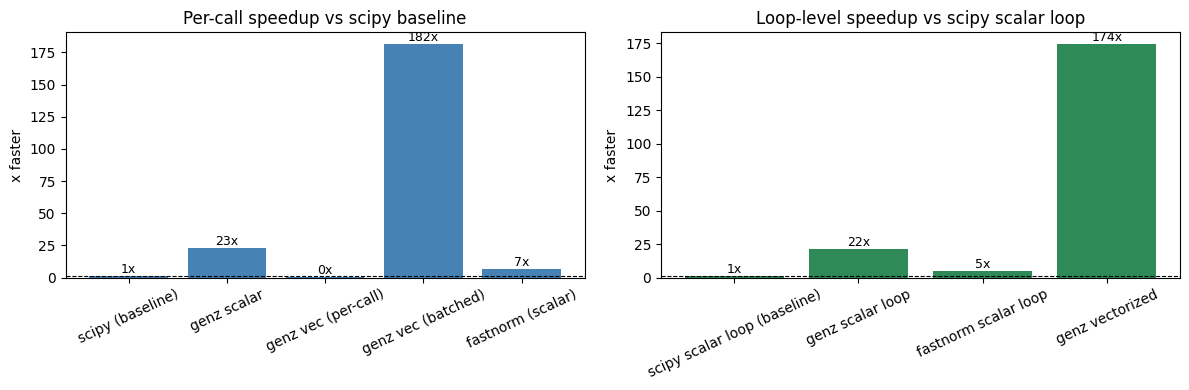

In [11]:
print("PER-CALL Phi_2 (us/call, lower is better):")
print(per_call.to_string(index=False))
print()
print("LOOP-LEVEL pairwise loglik, m=%d (ms/step):" % m)
print(loop_tbl.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(per_call["method"], per_call["speedup_x"], color="steelblue")
ax[0].set_title("Per-call speedup vs scipy baseline")
ax[0].set_ylabel("x faster")
ax[0].tick_params(axis="x", rotation=25)
ax[0].axhline(1.0, color="k", lw=0.8, ls="--")
for i, v in enumerate(per_call["speedup_x"]):
    ax[0].text(i, v, f"{v:.0f}x", ha="center", va="bottom", fontsize=9)

ax[1].bar(loop_tbl.iloc[:, 0], loop_tbl["speedup_x"], color="seagreen")
ax[1].set_title("Loop-level speedup vs scipy scalar loop")
ax[1].set_ylabel("x faster")
ax[1].tick_params(axis="x", rotation=25)
ax[1].axhline(1.0, color="k", lw=0.8, ls="--")
for i, v in enumerate(loop_tbl["speedup_x"]):
    ax[1].text(i, v, f"{v:.0f}x", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

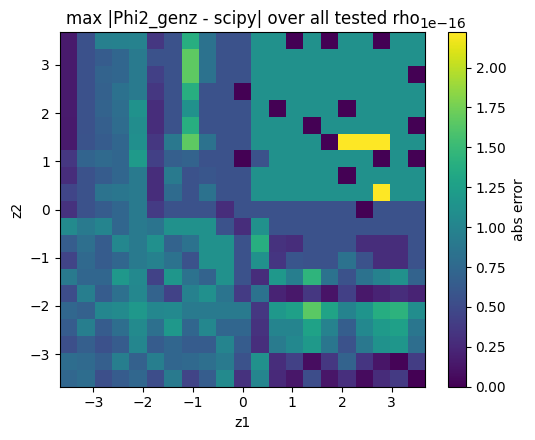

worst-case abs error anywhere on the mesh: 2.220446049250313e-16


In [12]:
# accuracy heatmap: max |error| of the vectorized method over the (z1,z2) mesh,
# worst case across all tested rho.
err_grid = err_vec.max(axis=0).reshape(Z1.shape)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.pcolormesh(zs, zs, err_grid, shading="auto", cmap="viridis")
ax.set_xlabel("z1"); ax.set_ylabel("z2")
ax.set_title("max |Phi2_genz - scipy| over all tested rho")
fig.colorbar(im, ax=ax, label="abs error")
plt.tight_layout()
plt.show()
print("worst-case abs error anywhere on the mesh:", err_grid.max())

## Conclusion & recommendation

- **Accuracy is fully preserved** by the in-house methods: both match scipy to
  $\sim10^{-15}$ across the whole mesh, including the $|r|\ge0.925$ branch — so
  `q_joint`, the four cell probabilities, `ll`, `sigma_hat` and the NaN handling
  of §3.4 are identical.
- **Method 1 (`phi2_genz_scalar`)** is the *lowest-risk* change to apply now: a
  pure drop-in for `phi2` that removes scipy's per-call object construction. Keep
  the `for j,k` loop unchanged.
- **Method 2 (`phi2_genz`)** is array-capable and unlocks the loop-level rewrite
  (one vectorized call per time step via `np.triu_indices`), which is the largest
  practical win. This is the deferred Deliverable 2.
- **Method 3 (`fastnorm`)** *is* a genuine speedup over scipy (≈5–7× per call),
  but it is the weakest option here on every axis that matters: it is the slowest
  of the accelerated methods (our own scalar Method 1 is ~3× faster, and batched
  Method 2 ~25× faster), it **cannot vectorize over $\rho$** (per-pair $\rho$
  forbids its shared-correlation batch path, so it never reaches Method 2's
  regime), it is only *approximate* ($\sim10^{-7}$ — enough to shift `ll` by
  $\sim10^{-2}$ at $m=60$ and so perturb `sigma_hat`), and it adds a third-party
  dependency. **Not recommended** — the in-house Genz code dominates it.

### LaTeX for the article (Deliverable 4)

A short remark to paste after `eq:sigma_Z_pair` in §3.3 (or a sentence in §5):

> Each bivariate Gaussian CDF $\Phi_2(\cdot,\cdot;\rho)$ in
> \eqref{eq:sigma_Z_pair} is evaluated with the Drezner–Wesolowsky / Genz
> Gauss–Legendre quadrature \citep{drezner1990, genz2004}, which is accurate to
> $\sim10^{-12}$, rather than with a general multivariate-normal routine. This
> makes the per-pair cost of the composite likelihood negligible.

BibTeX for `references.bib`:

```bibtex
@article{genz2004,
  author  = {Genz, Alan},
  title   = {Numerical computation of rectangular bivariate and trivariate normal and t probabilities},
  journal = {Statistics and Computing},
  volume  = {14},
  number  = {3},
  pages   = {251--260},
  year    = {2004},
  doi     = {10.1023/B:STCO.0000035304.20635.31}
}

@article{drezner1990,
  author  = {Drezner, Zvi and Wesolowsky, George O.},
  title   = {On the computation of the bivariate normal integral},
  journal = {Journal of Statistical Computation and Simulation},
  volume  = {35},
  number  = {1--2},
  pages   = {101--107},
  year    = {1990},
  doi     = {10.1080/00949659008811236}
}
```